# 2 · Model architecture & training -- v4 (V + M)

Builds directly on `v3`: the `M` section (two Kuramoto-coupled oscillator
populations) is unchanged. This notebook adds the `V` section in front of
it -- a small per-side feedforward stack with exactly **one** crossing
point, matching the senior's diagram and the discussion that followed it.

## What `V` is, and what it is not

`V` is a **one-time, stateless** connection -- recomputed fresh from each
timestep's `[position, target]` input, carrying no memory of its own. That
makes it structurally different from `M`'s coupling, which lives inside
the recurrence and compounds over all 99 steps. Biologically, `V` stands
in for the sparse, midline-restricted, largely structural connections seen
in visual callosal wiring; `M` stands in for the dynamic, persistent,
net-suppressive character of motor interhemispheric connections. Building
both means two distinct mechanisms are present, not the same mechanism
applied twice.

**Mix, not swap** -- confirmed against the diagram: at the one crossing
point, each side keeps its own features *and* adds a learned transform of
the other side's:

```
h2_L = ReLU( W_own_L(h1_L) + W_cross_R(h1_R) )
h2_R = ReLU( W_own_R(h1_R) + W_cross_L(h1_L) )
```

not a hard replacement of one side's features with the other's.

## Layer count

Three FC stages per side before the oscillators (`h1 -> h2[crossing] ->
h3`), matching the three boxes drawn between "L/R input" and the
oscillator layer in the diagram. `h3`'s output (width `v_hidden`) replaces
`v3`'s raw 4-dim `[position, target]` as what drives `input_r`/`input_i`
into the oscillators -- everything from the oscillators onward (`M`, the
Kuramoto coupling, the two readouts) is exactly `v3`, unmodified.

## Everything else is `v3`

Same `HopfCell` (`mu=1, beta=-1` fixed, `omega` fixed in the mu band),
same Kuramoto phase coupling (`kappa` fixed), same separate per-side
readouts, same training loop, same dual-population state saving. `V` is
the only addition.

In [1]:
from pathlib import Path

# This notebook lives in notebooks/, one level below the project root.
PROJECT_ROOT = Path.cwd().parent
print("PROJECT_ROOT:", PROJECT_ROOT.resolve())

PROJECT_ROOT: C:\Users\DELL\Desktop\mu_wave_desync


In [ ]:
import random
import pickle

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from complexPyTorch.complexLayers import ComplexLinear, ComplexReLU

OUTPUT_DIR = PROJECT_ROOT / "outputs_v4"
FIGURE_DIR = OUTPUT_DIR / "figures"

## GPU check

Diagnostics for what compute this notebook will actually run on.

In [3]:
print("Is CUDA available?", torch.cuda.is_available())

num_gpus = torch.cuda.device_count()
print(f"Number of GPUs available: {num_gpus}")

for i in range(num_gpus):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Selected device:", device)

Is CUDA available? False
Number of GPUs available: 0
Selected device: cpu


## `HopfCell`

Unchanged from `02_model_and_training_v2.ipynb`: `mu=1, beta=-1` fixed
(`rdot = r*(1 - r**2) + drive_r`), `omega` fixed in the mu band (buffer, not
learnable), native complex I/O. One addition: `forward` now accepts an
optional `phase_coupling` term — an extra value subtracted in the phase
update, computed by the caller. When it's `None` (the demo below), this is
byte-for-byte the same oscillator as `v2`.

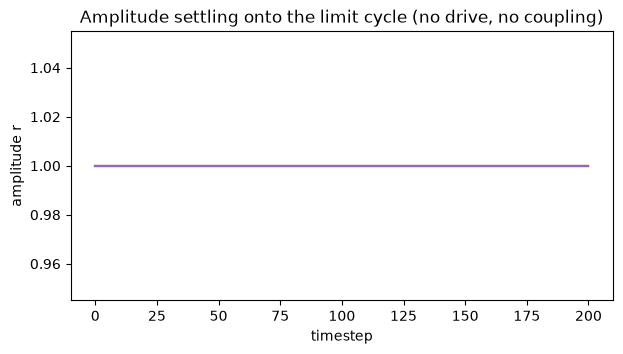

In [4]:
class HopfCell(nn.Module):
    """
    Bank of independent Hopf oscillators, native-complex I/O.

    rdot   = mu*r + beta*r**3 + drive_r         # mu=1, beta=-1 fixed -> r*(1 - r**2)
    phidot = omega - drive_phi - phase_coupling  # phase_coupling: optional Kuramoto term
    """

    MU = 1.0
    BETA = -1.0

    def __init__(self, units=50, min_freq=8.0, max_freq=13.0, dt=0.01, input_scaler=5.0):
        super().__init__()
        self.units = units
        self.dt = dt
        self.input_scaler = input_scaler

        freqs = torch.linspace(min_freq, max_freq, units)
        self.register_buffer("omega", 2 * np.pi * freqs)   # fixed, not an nn.Parameter

    def init_state(self, batch_size, device):
        r = torch.ones(batch_size, self.units, device=device)
        phi = torch.zeros(batch_size, self.units, device=device)
        return r, phi

    def forward(self, drive, r, phi, phase_coupling=None):
        """
        drive : complex tensor (B, units) = input_r + i*input_i
        r, phi: state (B, units) each, persisted by the caller across timesteps
        phase_coupling: optional (B, units) or (B,1) extra term, kappa*sin(psi_other - phi),
                        computed by the caller from a sibling oscillator population
        returns: z (complex, (B,units)), r_next, phi_next
        """
        drive_r = self.input_scaler * drive.real * torch.cos(phi)
        drive_phi = self.input_scaler * drive.imag * torch.sin(phi)

        # amplitude update (Hopf normal form, mu=1, beta=-1 fixed) -- coupling never touches this
        r_next = r + (self.MU * r + self.BETA * r**3 + drive_r) * self.dt

        # phase update -- this is where lateral coupling enters, if any
        coupling = phase_coupling if phase_coupling is not None else 0.0
        phi_next = phi + (self.omega.unsqueeze(0) - drive_phi - coupling) * self.dt

        z = torch.complex(r_next * torch.cos(phi_next), r_next * torch.sin(phi_next))

        return z, r_next, phi_next


# sanity check: uncoupled, should behave exactly like v2's HopfCell
cell = HopfCell(units=5, min_freq=8.0, max_freq=13.0, dt=0.01)
r, phi = cell.init_state(batch_size=1, device="cpu")
zero_drive = torch.zeros(1, 5, dtype=torch.cfloat)

r_hist = [r.clone()]
for t in range(200):
    _, r, phi = cell(zero_drive, r, phi)   # phase_coupling omitted -> None -> no coupling
    r_hist.append(r.clone())
r_hist = torch.cat(r_hist).detach().numpy()

plt.figure(figsize=(7, 3.5))
plt.plot(r_hist)
plt.xlabel("timestep"); plt.ylabel("amplitude r")
plt.title("Amplitude settling onto the limit cycle (no drive, no coupling)")
plt.show()

## `LateralizedHopfModelVM` (V + M)

`visual_encode` implements the `V` section described above; `forward_step`
is `v3`'s, unchanged except that it now calls `visual_encode(x)` first and
feeds its output into the oscillator drives instead of the raw
`[position, target]` slices.

In [ ]:
class LateralizedHopfModelVM(nn.Module):

    def __init__(self, n_osc_per_side=25, v_hidden=16, dt=0.005, input_scaler=5.0,
                 min_freq=8.0, max_freq=13.0, kappa=1.0, readout_hidden=32):
        super().__init__()
        self.n_osc = n_osc_per_side
        self.kappa = kappa

        # ---- V section: per-side genuinely-complex stack, one mix-not-swap
        # crossing. Mirrors the finalized concat-architecture DONN
        # (1d_track_concat_inv_vis_sweep_best.ipynb) -- ComplexLinear has an
        # actual complex weight (W_r + iW_i) and ties the real/imag outputs
        # together via true complex multiplication, unlike the old
        # input_r_L/input_i_L pair (two independent real Linears that only
        # *labeled* two unrelated numbers "real"/"imag").
        # +1 input: moving_flag (0=at rest, 1=in motion), alongside own
        # position + target.
        self.v1_L = ComplexLinear(5, v_hidden)
        self.v1_R = ComplexLinear(5, v_hidden)

        self.v2_own_L = ComplexLinear(v_hidden, v_hidden)
        self.v2_cross_R = ComplexLinear(v_hidden, v_hidden)   # R's h1 mixed into L's h2
        self.v2_own_R = ComplexLinear(v_hidden, v_hidden)
        self.v2_cross_L = ComplexLinear(v_hidden, v_hidden)   # L's h1 mixed into R's h2

        self.v3_L = ComplexLinear(v_hidden, v_hidden)
        self.v3_R = ComplexLinear(v_hidden, v_hidden)

        self.crelu = ComplexReLU()

        # ---- M section: one ComplexLinear per side projects the complex V
        # output straight into the complex oscillator drive -- replaces the
        # old input_r_L/input_i_L + torch.complex(...) packaging.
        self.to_drive_L = ComplexLinear(v_hidden, n_osc_per_side)
        self.to_drive_R = ComplexLinear(v_hidden, n_osc_per_side)

        self.hopf_L = HopfCell(units=n_osc_per_side, min_freq=min_freq, max_freq=max_freq,
                                dt=dt, input_scaler=input_scaler)
        self.hopf_R = HopfCell(units=n_osc_per_side, min_freq=min_freq, max_freq=max_freq,
                                dt=dt, input_scaler=input_scaler)

        # Readout stays "concatenated style" -- both real and imaginary parts
        # of the oscillator state reach the final Linear, matching the
        # sweep-winning concat_inv_vis architecture rather than an abs-only
        # (magnitude-only, phase-discarding) readout. Hidden layer uses
        # LeakyReLU since positions/targets are signed.
        self.readout_L = nn.Sequential(
            nn.Linear(2 * n_osc_per_side, readout_hidden), nn.LeakyReLU(),
            nn.Linear(readout_hidden, 2),
        )
        self.readout_R = nn.Sequential(
            nn.Linear(2 * n_osc_per_side, readout_hidden), nn.LeakyReLU(),
            nn.Linear(readout_hidden, 2),
        )

    def init_state(self, batch_size, device):
        r_L, phi_L = self.hopf_L.init_state(batch_size, device)
        r_R, phi_R = self.hopf_R.init_state(batch_size, device)
        return (r_L, phi_L, r_R, phi_R)

    def visual_encode(self, x):
        """x: (B,7) = [x_L,y_L,x_R,y_R,target_x,target_y,moving_flag]. Returns
        (enc_L, enc_R), each COMPLEX (B, v_hidden). Real input is embedded as
        complex with zero imaginary part -- same convention as DONN's
        `torch.complex(X, zeros_like(X))` -- then run through three
        ComplexLinear+ComplexReLU stages. moving_flag rides along on both
        sides so the network is explicitly told whether it's currently
        expected to hold still or reach."""
        target = x[:, 4:6]
        moving = x[:, 6:7]
        in_L = torch.cat([x[:, 0:2], target, moving], dim=1)
        in_R = torch.cat([x[:, 2:4], target, moving], dim=1)

        in_L_c = torch.complex(in_L, torch.zeros_like(in_L))
        in_R_c = torch.complex(in_R, torch.zeros_like(in_R))

        h1_L = self.crelu(self.v1_L(in_L_c))
        h1_R = self.crelu(self.v1_R(in_R_c))

        # the one crossing point -- mix, not swap (complex addition, then a
        # shared ComplexReLU, exactly mirroring how the real version applied
        # one relu to the summed pre-activation)
        h2_L = self.crelu(self.v2_own_L(h1_L) + self.v2_cross_R(h1_R))
        h2_R = self.crelu(self.v2_own_R(h1_R) + self.v2_cross_L(h1_L))

        h3_L = self.crelu(self.v3_L(h2_L))
        h3_R = self.crelu(self.v3_R(h2_R))
        return h3_L, h3_R

    def forward_step(self, x, state, return_diagnostics=False):
        """
        x     : (B, 7) = concat([prev_position (4) = [x_L,y_L,x_R,y_R], target (2), moving_flag (1)])
        state : (r_L, phi_L, r_R, phi_R)
        returns: pred_coords (B, 4) = [x_L,y_L,x_R,y_R], new_state[, diagnostics]
        """
        r_L, phi_L, r_R, phi_R = state
        enc_L, enc_R = self.visual_encode(x)

        drive_L = self.to_drive_L(enc_L)
        drive_R = self.to_drive_R(enc_R)

        z_L_now = torch.complex(r_L * torch.cos(phi_L), r_L * torch.sin(phi_L))
        z_R_now = torch.complex(r_R * torch.cos(phi_R), r_R * torch.sin(phi_R))
        psi_L = torch.angle(z_L_now.mean(dim=1, keepdim=True))
        psi_R = torch.angle(z_R_now.mean(dim=1, keepdim=True))

        coupling_into_L = self.kappa * torch.sin(psi_R - phi_L)
        coupling_into_R = self.kappa * torch.sin(psi_L - phi_R)

        z_L, r_L_next, phi_L_next = self.hopf_L(drive_L, r_L, phi_L, phase_coupling=coupling_into_L)
        z_R, r_R_next, phi_R_next = self.hopf_R(drive_R, r_R, phi_R, phase_coupling=coupling_into_R)

        feat_L = torch.cat([z_L.real, z_L.imag], dim=1)
        feat_R = torch.cat([z_R.real, z_R.imag], dim=1)

        pred = torch.cat([self.readout_L(feat_L), self.readout_R(feat_R)], dim=1)
        new_state = (r_L_next, phi_L_next, r_R_next, phi_R_next)

        if return_diagnostics:
            diag = {"z_L": z_L, "z_R": z_R, "r_L": r_L_next, "r_R": r_R_next,
                    "phi_L": phi_L_next, "phi_R": phi_R_next}
            return pred, new_state, diag
        return pred, new_state


model = LateralizedHopfModelVM().to(device)
print("Model is running on:", next(model.parameters()).device)
print(f"kappa (fixed, Kuramoto coupling strength): {model.kappa}")

state = model.init_state(batch_size=8, device=device)
x = torch.randn(8, 7).to(device)
pred, state = model.forward_step(x, state)

print("pred shape:", pred.shape)
pred.mean().backward()
print("Backward pass successful")

freqs_L = model.hopf_L.omega.detach().cpu() / (2 * torch.pi)
freqs_R = model.hopf_R.omega.detach().cpu() / (2 * torch.pi)
print("First 5 L-population frequencies (Hz, fixed in mu band):", freqs_L[:5].numpy())
print("First 5 R-population frequencies (Hz, fixed in mu band):", freqs_R[:5].numpy())

## `TrajectoryDataset`

Extended from notebooks 01/02/v2/v3: each raw 100-step trajectory (which is
*always already in motion* -- position changes every step, even at t=0) is
now padded with genuine held-still "rest" steps before and after -- the
hand literally does not move, at the trajectory's own start/end position --
and paired with a ground-truth `moving_flag` (0 during the padding, 1
during the real 100 reach steps). This replaces the *inferred* pre/active/post
segmentation the analysis notebook (`03_mu_desynchrony_analysis.ipynb`) had
to do heuristically from the distance-to-target curve with an *exact*,
known-by-construction boundary -- needed to test mu-band synchrony during
true rest vs. desynchrony during real movement.

In [ ]:
class TrajectoryDataset(Dataset):

    def __init__(self, root_dir, pad_pre=20, pad_post=20):
        root_dir = Path(root_dir)
        self.pad_pre = pad_pre
        self.pad_post = pad_post

        with open(root_dir / "data" / "raw" / "splined_trajectories_100.txt", "rb") as f:
            self.trajectories = pickle.load(f)
        with open(root_dir / "data" / "processed" / "targets_100.pkl", "rb") as f:
            self.targets = pickle.load(f)
        with open(root_dir / "data" / "processed" / "active_arms_100.pkl", "rb") as f:
            self.active_arms = pickle.load(f)

        assert len(self.trajectories) == len(self.targets) == len(self.active_arms)
        print(f"Loaded {len(self.trajectories)} trajectories, padded with "
              f"{pad_pre} held-still rest steps before / {pad_post} after "
              f"(hand held at the trajectory's own start/end position)")

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = np.asarray(self.trajectories[idx], dtype=np.float32)   # (100, 4)
        target = np.asarray(self.targets[idx], dtype=np.float32)
        active_arm = np.int64(self.active_arms[idx])

        # Rest padding: hand held still at the true start/end position -- a
        # genuine at-rest baseline, not just "early/late in an already-moving
        # trajectory". moving_flag is the ground-truth label: 0 = at rest
        # (padding), 1 = real, in-motion reach data.
        pre = np.repeat(traj[0:1], self.pad_pre, axis=0)
        post = np.repeat(traj[-1:], self.pad_post, axis=0)
        traj_padded = np.concatenate([pre, traj, post], axis=0)

        moving_flag = np.concatenate([
            np.zeros(self.pad_pre, dtype=np.float32),
            np.ones(traj.shape[0], dtype=np.float32),
            np.zeros(self.pad_post, dtype=np.float32),
        ])

        return (torch.from_numpy(traj_padded), torch.from_numpy(target),
                torch.from_numpy(moving_flag), torch.tensor(active_arm))

## Training

Identical schedule and saving logic to `v3` -- only the model class
differs (`LateralizedHopfModelVM` instead of `LateralizedHopfModel`, with
the added `v_hidden` argument for the `V` section's width). Outputs land
in `outputs_v4/`, separate from every other variant.

In [ ]:
def teacher_forcing_prob(epoch, epochs, start=1.0, end=0.1):
    frac = (epoch - 1) / max(1, epochs - 1)
    return start + (end - start) * frac


def collect_oscillator_states(traj_batch, target_batch, moving_batch, model, device):
    """Same as v3 -- pure autoregressive rollout, records both populations' z/r/phi."""
    B, T = traj_batch.shape[0], traj_batch.shape[1]
    state = model.init_state(batch_size=B, device=device)
    prev = traj_batch[:, 0]

    rec = {side: {"z_real": [], "z_imag": [], "r": [], "phi": []} for side in ("L", "R")}

    for t in range(1, T):
        moving_t = moving_batch[:, t:t + 1]
        inp = torch.cat([prev, target_batch, moving_t], dim=1)
        pred, state, diag = model.forward_step(inp, state, return_diagnostics=True)

        for side in ("L", "R"):
            rec[side]["z_real"].append(diag[f"z_{side}"].real.detach().cpu().numpy())
            rec[side]["z_imag"].append(diag[f"z_{side}"].imag.detach().cpu().numpy())
            rec[side]["r"].append(diag[f"r_{side}"].detach().cpu().numpy())
            rec[side]["phi"].append(diag[f"phi_{side}"].detach().cpu().numpy())

        prev = pred

    out = {}
    for side in ("L", "R"):
        for k in ("z_real", "z_imag", "r", "phi"):
            out[f"{k}_{side}"] = np.stack(rec[side][k], axis=0).transpose(1, 0, 2)
    return out


def train(
    epochs=1000, batch_size=16, learning_rate=1e-3, seed=42,
    n_osc_per_side=25, v_hidden=16, dt=0.005, input_scaler=5.0,
    freq_min=8.0, freq_max=13.0, kappa=1.0, readout_hidden=32,
    teacher_forcing_start=1.0, teacher_forcing_end=0.1,
    pad_pre=20, pad_post=20,
):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(device))

    dataset = TrajectoryDataset(PROJECT_ROOT, pad_pre=pad_pre, pad_post=pad_post)

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(
        dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(seed)
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    print(f"Dataset: {len(dataset)} | Train: {len(train_dataset)} | Val: {len(val_dataset)}")

    model = LateralizedHopfModelVM(
        n_osc_per_side=n_osc_per_side, v_hidden=v_hidden, dt=dt, input_scaler=input_scaler,
        min_freq=freq_min, max_freq=freq_max, kappa=kappa, readout_hidden=readout_hidden,
    ).to(device)
    print("Model is running on:", next(model.parameters()).device)
    print(f"kappa (fixed): {kappa}")

    np.save(OUTPUT_DIR / "kappa.npy", np.array([kappa], dtype=np.float32))
    initial_freqs_L = (model.hopf_L.omega.detach().cpu() / (2 * torch.pi)).numpy()
    initial_freqs_R = (model.hopf_R.omega.detach().cpu() / (2 * torch.pi)).numpy()
    np.save(OUTPUT_DIR / "initial_frequencies_L.npy", initial_freqs_L)
    np.save(OUTPUT_DIR / "initial_frequencies_R.npy", initial_freqs_R)
    print(f"L frequency range: {initial_freqs_L.min():.2f} - {initial_freqs_L.max():.2f} Hz")
    print(f"R frequency range: {initial_freqs_R.min():.2f} - {initial_freqs_R.max():.2f} Hz")

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    history = {"train_loss": [], "val_loss": [], "teacher_forcing": []}
    best_val_loss = float("inf")

    for epoch in range(1, epochs + 1):
        tf_prob = teacher_forcing_prob(epoch, epochs, teacher_forcing_start, teacher_forcing_end)

        model.train()
        train_loss_epoch = 0.0

        for traj_batch, target_batch, moving_batch, _ in train_loader:
            traj_batch = traj_batch.to(device)
            target_batch = target_batch.to(device)
            moving_batch = moving_batch.to(device)
            B, T = traj_batch.shape[0], traj_batch.shape[1]

            state = model.init_state(batch_size=B, device=device)
            prev = traj_batch[:, 0]
            loss = 0.0
            optimizer.zero_grad()

            for t in range(1, T):
                moving_t = moving_batch[:, t:t + 1]
                inp = torch.cat([prev, target_batch, moving_t], dim=1)
                pred, state = model.forward_step(inp, state)
                gt = traj_batch[:, t]
                loss += loss_fn(pred, gt)

                prev = gt if random.random() < tf_prob else pred.detach()

            loss = loss / (T - 1)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss_epoch += loss.item()

        train_loss_epoch /= len(train_loader)

        model.eval()
        val_loss_epoch = 0.0

        with torch.no_grad():
            for traj_batch, target_batch, moving_batch, _ in val_loader:
                traj_batch = traj_batch.to(device)
                target_batch = target_batch.to(device)
                moving_batch = moving_batch.to(device)
                B, T = traj_batch.shape[0], traj_batch.shape[1]

                state = model.init_state(batch_size=B, device=device)
                prev = traj_batch[:, 0]
                loss = 0.0

                for t in range(1, T):
                    moving_t = moving_batch[:, t:t + 1]
                    inp = torch.cat([prev, target_batch, moving_t], dim=1)
                    pred, state = model.forward_step(inp, state)
                    gt = traj_batch[:, t]
                    loss += loss_fn(pred, gt)
                    prev = pred

                loss = loss / (T - 1)
                val_loss_epoch += loss.item()

        val_loss_epoch /= len(val_loader)

        history["train_loss"].append(train_loss_epoch)
        history["val_loss"].append(val_loss_epoch)
        history["teacher_forcing"].append(tf_prob)

        if val_loss_epoch < best_val_loss:
            best_val_loss = val_loss_epoch

            torch.save({
                "epoch": epoch, "val_loss": val_loss_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
            }, OUTPUT_DIR / "best_hopf_model.pt")

            osc_states = {"traj_gt": [], "target": [], "moving_flag": []}
            for side in ("L", "R"):
                for k in ("z_real", "z_imag", "r", "phi"):
                    osc_states[f"{k}_{side}"] = []

            with torch.no_grad():
                for traj_batch, target_batch, moving_batch, _ in val_loader:
                    traj_batch = traj_batch.to(device)
                    target_batch = target_batch.to(device)
                    moving_batch = moving_batch.to(device)

                    batch_states = collect_oscillator_states(traj_batch, target_batch, moving_batch, model, device)

                    for b in range(traj_batch.shape[0]):
                        for key, arr in batch_states.items():
                            osc_states[key].append(arr[b])
                        osc_states["traj_gt"].append(traj_batch[b].cpu().numpy())
                        osc_states["target"].append(target_batch[b].cpu().numpy())
                        # moving_flag[1:] to line up with the oscillator states above,
                        # which start recording at t=1 (t=0 is the given starting state).
                        osc_states["moving_flag"].append(moving_batch[b, 1:].cpu().numpy())

            np.savez(
                OUTPUT_DIR / "best_oscillator_states.npz",
                **{k: np.array(v, dtype=object) for k, v in osc_states.items()},
            )

        print(f"Epoch {epoch:04d} | Train {train_loss_epoch:.6f} | Val {val_loss_epoch:.6f} | TF {tf_prob:.4f}")

    print("\nTraining complete.")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history["train_loss"], label="Train loss")
    ax.plot(history["val_loss"], label="Val loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE loss")
    ax.set_title("Training curve")
    ax.legend(); ax.grid(True, alpha=0.3)
    fig.savefig(FIGURE_DIR / "loss_curve.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved loss curve -> {FIGURE_DIR / 'loss_curve.png'}")

    return model, history


model, history = train(epochs=1000)

## Loss curve

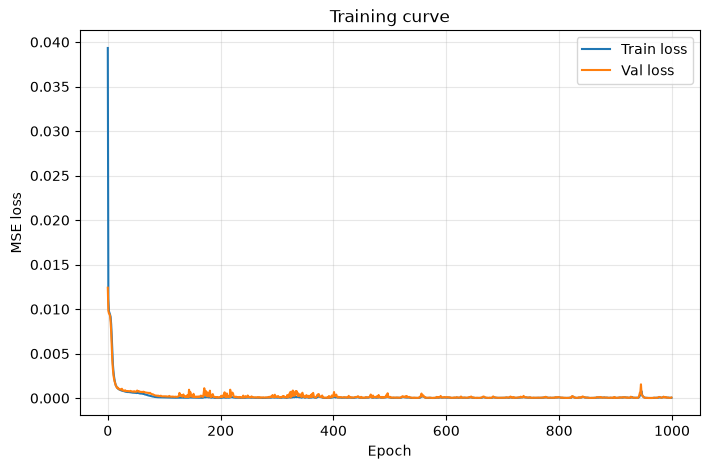

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history["train_loss"], label="Train loss")
ax.plot(history["val_loss"], label="Val loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE loss")
ax.set_title("Training curve")
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## Sanity-check: predicted vs ground-truth trajectories

Same procedure as `v2`: pure autoregression (no teacher forcing) on held-out
trajectories, active-arm path plotted against ground truth, then mean
position error across the rollout for the whole validation set. Reused
as-is -- `forward_step(x, state)` returns `(pred, state)` in the same shape
as `v2`, so nothing here needed to change.

In [ ]:
def active_cols(traj):
    """traj: (T,4) array. Returns the (x,y) column slice for whichever arm moved further."""
    left_travel = np.linalg.norm(traj[-1, :2] - traj[0, :2])
    right_travel = np.linalg.norm(traj[-1, 2:] - traj[0, 2:])
    return slice(0, 2) if left_travel > right_travel else slice(2, 4)


def autoregressive_rollout(model, traj_gt, target, moving_flag, device):
    """traj_gt: (T,4) tensor, target: (2,) tensor, moving_flag: (T,) tensor.
    Returns predicted (T,4) numpy array, generated the same way validation
    does: pure autoregression, no teacher forcing. moving_flag is exogenous
    ground truth (known in advance regardless of teacher forcing) so it's
    just read off at every step, never predicted."""
    traj_gt = traj_gt.unsqueeze(0).to(device)
    target_b = target.unsqueeze(0).to(device)
    moving_b = moving_flag.unsqueeze(0).to(device)
    state = model.init_state(batch_size=1, device=device)
    prev = traj_gt[:, 0]
    preds = [prev]
    with torch.no_grad():
        for t in range(1, traj_gt.shape[1]):
            moving_t = moving_b[:, t:t + 1]
            inp = torch.cat([prev, target_b, moving_t], dim=1)
            pred, state = model.forward_step(inp, state)
            preds.append(pred)
            prev = pred
    return torch.cat(preds, dim=0).cpu().numpy()


dataset = TrajectoryDataset(PROJECT_ROOT)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
_, val_dataset = random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

model.eval()
n_show = 4
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))

for i in range(n_show):
    traj_gt, target, moving_flag, _ = val_dataset[i]
    gt_traj = traj_gt.numpy()
    pred_traj = autoregressive_rollout(model, traj_gt, target, moving_flag, device)
    cols = active_cols(gt_traj)

    ax = axes[i]
    ax.plot(gt_traj[:, cols][:, 0], gt_traj[:, cols][:, 1], "o-", ms=2, color="steelblue", label="Ground truth")
    ax.plot(pred_traj[:, cols][:, 0], pred_traj[:, cols][:, 1], "o-", ms=2, color="crimson", label="Predicted")
    ax.scatter(*target.numpy(), marker="*", s=150, color="black", zorder=5, label="Target")
    ax.set_title(f"Val trajectory {i}")
    ax.set_aspect("equal")
    if i == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
n_check = len(val_dataset)
T_total = val_dataset[0][0].shape[0]   # 100 + pad_pre + pad_post, not hardcoded 99 anymore
errors = np.zeros((n_check, T_total - 1))

for i in range(n_check):
    traj_gt, target, moving_flag, _ = val_dataset[i]
    gt_traj = traj_gt.numpy()
    pred_traj = autoregressive_rollout(model, traj_gt, target, moving_flag, device)
    cols = active_cols(gt_traj)
    errors[i] = np.linalg.norm(pred_traj[1:, cols] - gt_traj[1:, cols], axis=1)

plt.figure(figsize=(7, 4))
mean_err, std_err = errors.mean(axis=0), errors.std(axis=0)
plt.plot(mean_err, color="crimson")
plt.fill_between(range(T_total - 1), mean_err - std_err, mean_err + std_err, color="crimson", alpha=0.2)
plt.xlabel("Timestep"); plt.ylabel("Euclidean position error (active arm, m)")
plt.title(f"Autoregressive rollout error over {n_check} val trajectories")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean error over full rollout: {errors.mean():.4f}  |  Final-step mean error: {errors[:, -1].mean():.4f}")

**Next:** compare this notebook's results against `v3`'s -- does adding
the `V` crossing change prediction accuracy, ERD, or lateralization,
relative to the `M`-only version? A shared analysis notebook that loads
either `outputs_v3/` or `outputs_v4/` and computes per-population ERD plus
the Kuramoto order parameter between the two populations (as a phase-sync
/ mu-synchrony measure) is the natural next build, once both of these
have been trained and compared.